# The two-player leg: how much is the opponent worth?

The single-player MDP answers "how do I finish in the fewest darts?". That is a proxy. What
a player actually wants is to finish *first*.

A leg is a turn-based zero-sum game with perfect information -- only the player at the oche
acts -- so it has a value in pure strategies and yields to backward induction. Write

$$W[u, v] = \Pr(\text{the player about to throw, on } u, \text{ beats an opponent on } v).$$

If my visit ends leaving me on $u'$, my opponent throws next, so my chance from there is
$1 - W[v, u']$. Checking out wins immediately.

## Why 250,000 states is affordable

1. **Order by the total $u + v$.** $W[u, v]$ depends on $W[v, u']$ with $u' \le u$, so
   almost every dependency points strictly backwards. The single exception is $u' = u$ --
   a visit that makes no progress -- which couples $W[u, v]$ to $W[v, u]$, its mirror on
   the same diagonal. Each diagonal is therefore a small fixed point among its own pairs.
2. **A diagonal is one matrix multiply.** Every pair on it applies the same
   `(n_points x n_scores)` transition matrix to its own continuation vector.
3. **The within-visit values stop depending on the visit's starting score** above the same
   thresholds as in the single-player model (see notebook 01), so only scores below 182
   need per-visit-start sweeps.

A full 501 leg with three darts a turn solves in about 15 minutes.

In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..', '..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
    'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 11, 'font.size': 9, 'legend.frameon': False,
})

from darts.transitions import transition_arrays
from darts.mdp_2player import ThreeDartLeg
from darts.mdp_3turn import ThreeDartMDP
from darts.utils import region_label

RESULT = os.path.join(module_path, 'results', 'leg3_501_sigma15.npz')
print('pre-solved leg available:', os.path.exists(RESULT))

pre-solved leg available: True


The solved leg is committed so this notebook runs without a 15-minute wait. To regenerate
it, or to solve for a different player:

```bash
python scripts/solve_2player_leg.py --sigma 15 --out results/leg3_501_sigma15.npz
```

The script checkpoints every 25 diagonals and takes `--resume`, so it is safe to interrupt.

In [2]:
d = np.load(RESULT)
W, POL, pts, S = d['W'], d['policy'], d['points'], d['allowed_scores']
G, BP, SIG = W.shape[0] - 1, int(d['board_pixels']), float(d['sigma'])
print(f'sigma = {SIG} mm, board = {BP} px, {len(pts)} aiming points, game_start = {G}')
print(f'\nP(win | both on 501, throwing first) = {W[501, 501]:.4f}')

sigma = 15.0 mm, board = 512 px, 293 aiming points, game_start = 501

P(win | both on 501, throwing first) = 0.5725


## What throwing first is worth

Winning the bull-up is worth 7 points of win probability over a full leg, and it grows as
the leg shortens -- with fewer visits left there is less time for the disadvantage to wash
out.

both players on,501,301,170,120,80,40,20,10,2
P(win) throwing first,0.5725,0.5825,0.5952,0.5975,0.6063,0.6421,0.6345,0.6138,0.6019


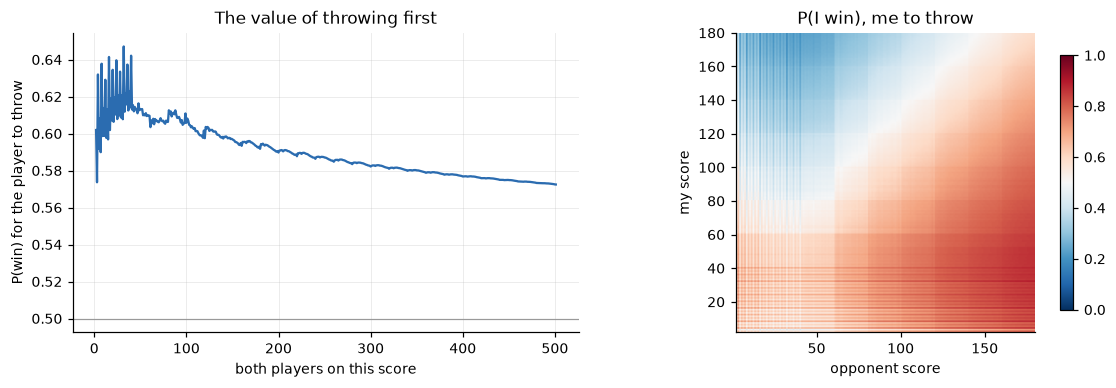

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6))
eq = np.arange(2, G + 1)
axes[0].plot(eq, [W[u, u] for u in eq], color='#2b6cb0', lw=1.5)
axes[0].axhline(0.5, color='0.6', lw=0.8)
axes[0].set_xlabel('both players on this score')
axes[0].set_ylabel('P(win) for the player to throw')
axes[0].set_title('The value of throwing first')

im = axes[1].imshow(W[2:181, 2:181], origin='lower', cmap='RdBu_r', vmin=0, vmax=1,
                    extent=[2, 180, 2, 180])
axes[1].set_xlabel('opponent score'); axes[1].set_ylabel('my score')
axes[1].set_title('P(I win), me to throw')
axes[1].grid(False)
fig.colorbar(im, ax=axes[1], shrink=0.85)
fig.tight_layout()

pd.DataFrame({'both players on': [501, 301, 170, 120, 80, 40, 20, 10, 2],
              'P(win) throwing first': [round(W[s, s], 4) for s in
                                        [501, 301, 170, 120, 80, 40, 20, 10, 2]]}
             ).set_index('both players on').T

## Does the opponent change what you should aim at?

This is the question the two-player game exists to answer. The tempting way to measure it
is to count states where the win-maximising aim differs from the single-player one -- and
that measure is **wrong**, in a way worth spelling out because it is easy to fall for.

Many aiming points are near-ties. When two points are worth 0.4999 and 0.5000, the argmax
flips between them on the strength of a rounding difference, and a "policy change" gets
counted that is worth a millionth of a leg. What matters is **how much win probability you
give up** by ignoring the opponent. Let us compute both and compare.

In [4]:
# rebuild the same reduced transition model the leg was solved on
tr = transition_arrays(BP, SIG, point_stride=4)
idx = {tuple(p): i for i, p in enumerate(tr['points'])}
keep = np.array([idx[tuple(p)] for p in pts])
P = np.ascontiguousarray(tr['probs'][keep])
CP = np.ascontiguousarray(tr['checkout_probs'][keep])

# the single-player policy: minimise expected VISITS, the right proxy in a race
sp = ThreeDartMDP(P, CP, S, G, dart_cost=0.0, turn_cost=1.0).solve()
print(f'single-player: {sp.expected_darts():.3f} expected visits from 501')

leg = ThreeDartLeg(P, CP, S, G)     # for its transition bookkeeping only
Y2 = d['Y2']


def win_q(u, v):
    '''Win probability of each aiming point, first dart of a visit, me on u vs v.'''
    k = leg.k_valid[u]
    g = np.zeros(leg.n_scores)
    g[1:k] = Y2[v, u - S[1:k]]
    e = 1.0 - W[v, u]                    # my visit ending back where it started
    return leg.PT.T @ g + leg.co[u] + leg.bust[u] * e + leg.P0 * Y2[v, u]


us = np.arange(2, 201)
vs = np.concatenate([np.arange(2, 201, 2), [250, 301, 351, 401, 451, 501]])
loss = np.zeros((len(us), len(vs)))
argmax_differs = np.zeros_like(loss, dtype=bool)
for a, u in enumerate(us):
    for b, v in enumerate(vs):
        q = win_q(u, v)
        loss[a, b] = q.max() - q[sp.pol1[u]]
        argmax_differs[a, b] = POL[u, v] != sp.pol1[u]

print(f'\nargmax differs in {argmax_differs.mean():.1%} of sampled states')
print(f'  worth more than 0.001 of win probability: {(loss > 0.001).mean():.1%}')
print(f'  worth more than 0.01:                     {(loss > 0.01).mean():.2%}')
print(f'\nlargest loss anywhere:                {loss.max():.4f}')
print(f'largest with my score > 120:          {loss[us > 120].max():.5f}')
print(f'largest with my score in 61..120:     {loss[(us > 60) & (us <= 120)].max():.5f}')
print(f'largest with my score <= 60:          {loss[us <= 60].max():.4f}')

single-player: 9.626 expected visits from 501



argmax differs in 25.2% of sampled states
  worth more than 0.001 of win probability: 5.1%
  worth more than 0.01:                     0.35%

largest loss anywhere:                0.0144
largest with my score > 120:          0.00180
largest with my score in 61..120:     0.01291
largest with my score <= 60:          0.0144


There it is. A quarter of the states have a different argmax, but only 5% of them are worth
as much as a thousandth of a leg, and a third of a percent are worth more than 1%.

**Ignoring the opponent entirely costs at most 1.4 points of win probability**, and the
cost is concentrated where you would expect: at the finish.

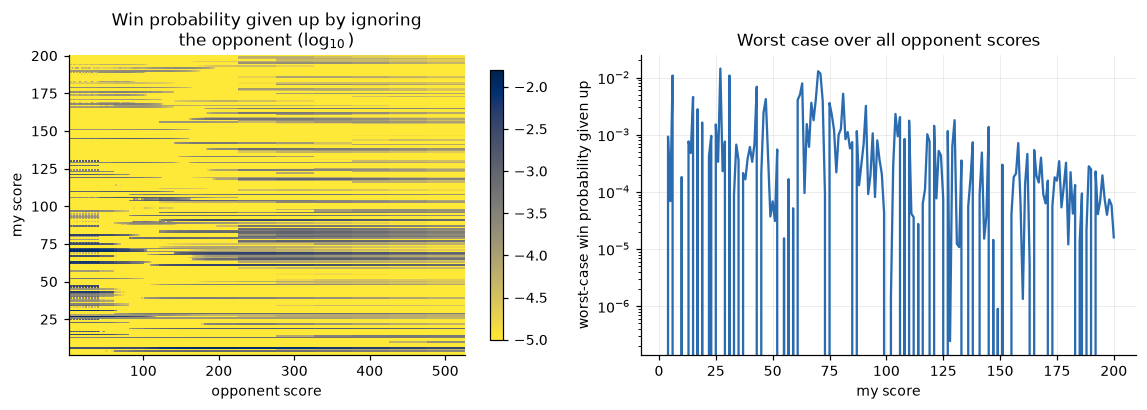

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
im = axes[0].pcolormesh(vs, us, np.log10(np.maximum(loss, 1e-8)),
                        cmap='cividis_r', vmin=-5, vmax=-1.8)
axes[0].set_xlabel('opponent score'); axes[0].set_ylabel('my score')
axes[0].set_title('Win probability given up by ignoring\nthe opponent ($\\log_{10}$)')
axes[0].grid(False)
fig.colorbar(im, ax=axes[0], shrink=0.9)

axes[1].plot(us, loss.max(axis=1), color='#2b6cb0', lw=1.5)
axes[1].set_yscale('log')
axes[1].set_xlabel('my score')
axes[1].set_ylabel('worst-case win probability given up')
axes[1].set_title('Worst case over all opponent scores')
fig.tight_layout()

## Where it actually matters

The states worth more than half a point of win probability, and what changes.

In [6]:
rows = []
for a, b in np.argwhere(loss > 0.004):
    u, v = us[a], vs[b]
    q = win_q(u, v)
    rows.append({'my score': u, 'opponent': v,
                 'win-maximising': region_label(pts[q.argmax()], BP),
                 'min-visits': region_label(pts[sp.pol1[u]], BP),
                 'P(win) cost': round(loss[a, b], 4)})
top = pd.DataFrame(rows).sort_values('P(win) cost', ascending=False)
top.drop_duplicates('my score').head(12).set_index(['my score', 'opponent'])

,,win-maximising,min-visits,P(win) cost
my score,opponent,,,
27,32,19,miss,0.0144
70,32,T14,19,0.0129
71,32,T13,19,0.0117
6,188,2,D3,0.0109
31,32,7,15,0.0108
63,24,BULL,15,0.0079
43,32,3,11,0.0069
81,16,BULL,T19,0.0052
62,32,T14,T10,0.0050


The pattern is the one darts players describe: **when the opponent is about to check out,
you stop protecting your number and start making progress towards a double**, even at the
cost of leaving yourself awkward. The single-player policy will happily throw a dart off
the board to preserve a good number; the win-maximising policy will not do that when it is
about to lose.

## Conclusion

* Throwing first in a 501 leg is worth about 7 points of win probability at
  $\sigma = 15$ mm, rising as the leg shortens.
* **Knowing the opponent's score is worth at most ~1.4 points**, and only in the endgame.
  Above a score of 120 it is worth less than 0.2 points.
* Practically: use the single-player policy for the scoring phase, and the two-player
  policy from about 120 down. That is convenient, because the low-score region is also the
  cheap part of the game to solve.
* Methodologically: **do not measure policy differences by counting argmax changes.** It
  overstates them roughly fivefold here.